In [6]:
!pip install kagglehub

In [7]:
import os
import shutil
import random
import pandas as pd
import numpy as np

from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

    
import warnings
warnings.filterwarnings("ignore")

sns.set_style("darkgrid")
sns.set_palette("viridis")

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anrreddy/i-will-tell-you3")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/anrreddy/i-will-tell-you3


In [9]:

source_path = os.path.join(path,"dataset_split")
destination_path = os.getcwd()
train_dir = os.path.join(source_path, "train")
test_dir = os.path.join(source_path, "val") 

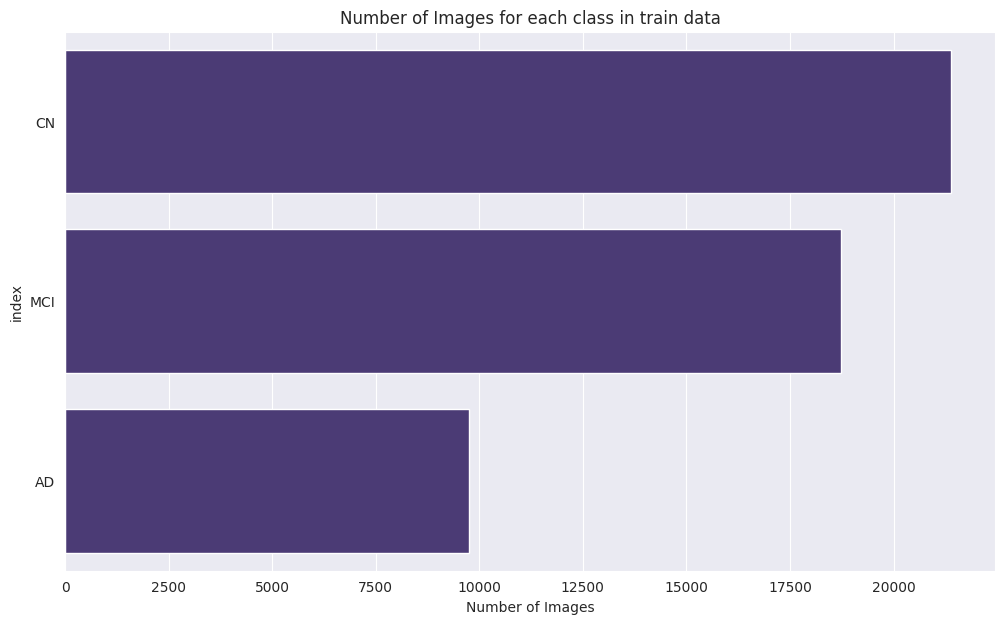

In [10]:
#Plotting number of images in train data
num_images_train = {}

for folder in os.listdir(train_dir):
  num_images_train[folder] = len(os.listdir(os.path.join(train_dir,folder)))

plt.figure(figsize=(12,7))
sns.barplot(
    data = pd.DataFrame.from_dict(num_images_train,orient="index", columns=['Number of Images'])\
    .reset_index().sort_values(by="Number of Images", ascending=False),
    x="Number of Images",
    y = "index",
    orient="h",
)
plt.title("Number of Images for each class in train data")
plt.show()

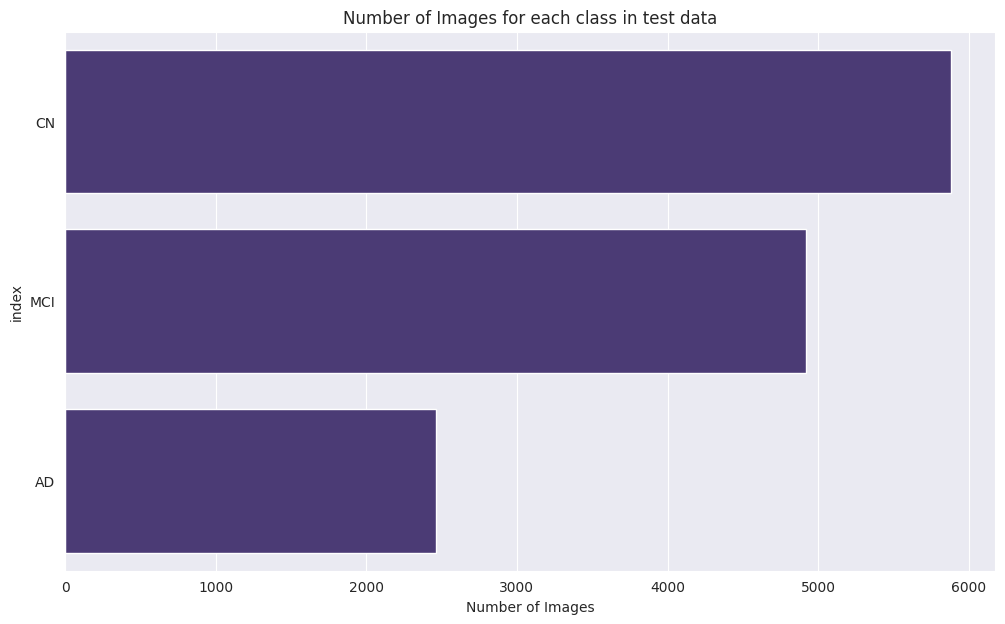

In [11]:
#Plotting Number of images in test data
num_images_test = {}

for folder in os.listdir(test_dir):
  num_images_test[folder] = len(os.listdir(os.path.join(test_dir,folder)))

plt.figure(figsize=(12,7))
sns.barplot(
    data = pd.DataFrame.from_dict(num_images_test,orient="index", columns=['Number of Images'])\
    .reset_index().sort_values(by="Number of Images", ascending=False),
    x="Number of Images",
    y = "index",
    orient="h",
)
plt.title("Number of Images for each class in test data")
plt.show()

In [ ]:
data_gen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.efficientnet_v2.preprocess_input
)


train_data = data_gen.flow_from_directory(
    train_dir,
    target_size=(300,300),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32,
    shuffle=True,
    seed=42
)

test_data = data_gen.flow_from_directory(
    test_dir,
    target_size=(300,300),
    color_mode="rgb",
    class_mode="categorical",
    batch_size=32,
    shuffle=False,
    seed=42
)

In [35]:
train_data.class_indices

{'AD': 0, 'CN': 1, 'MCI': 2}

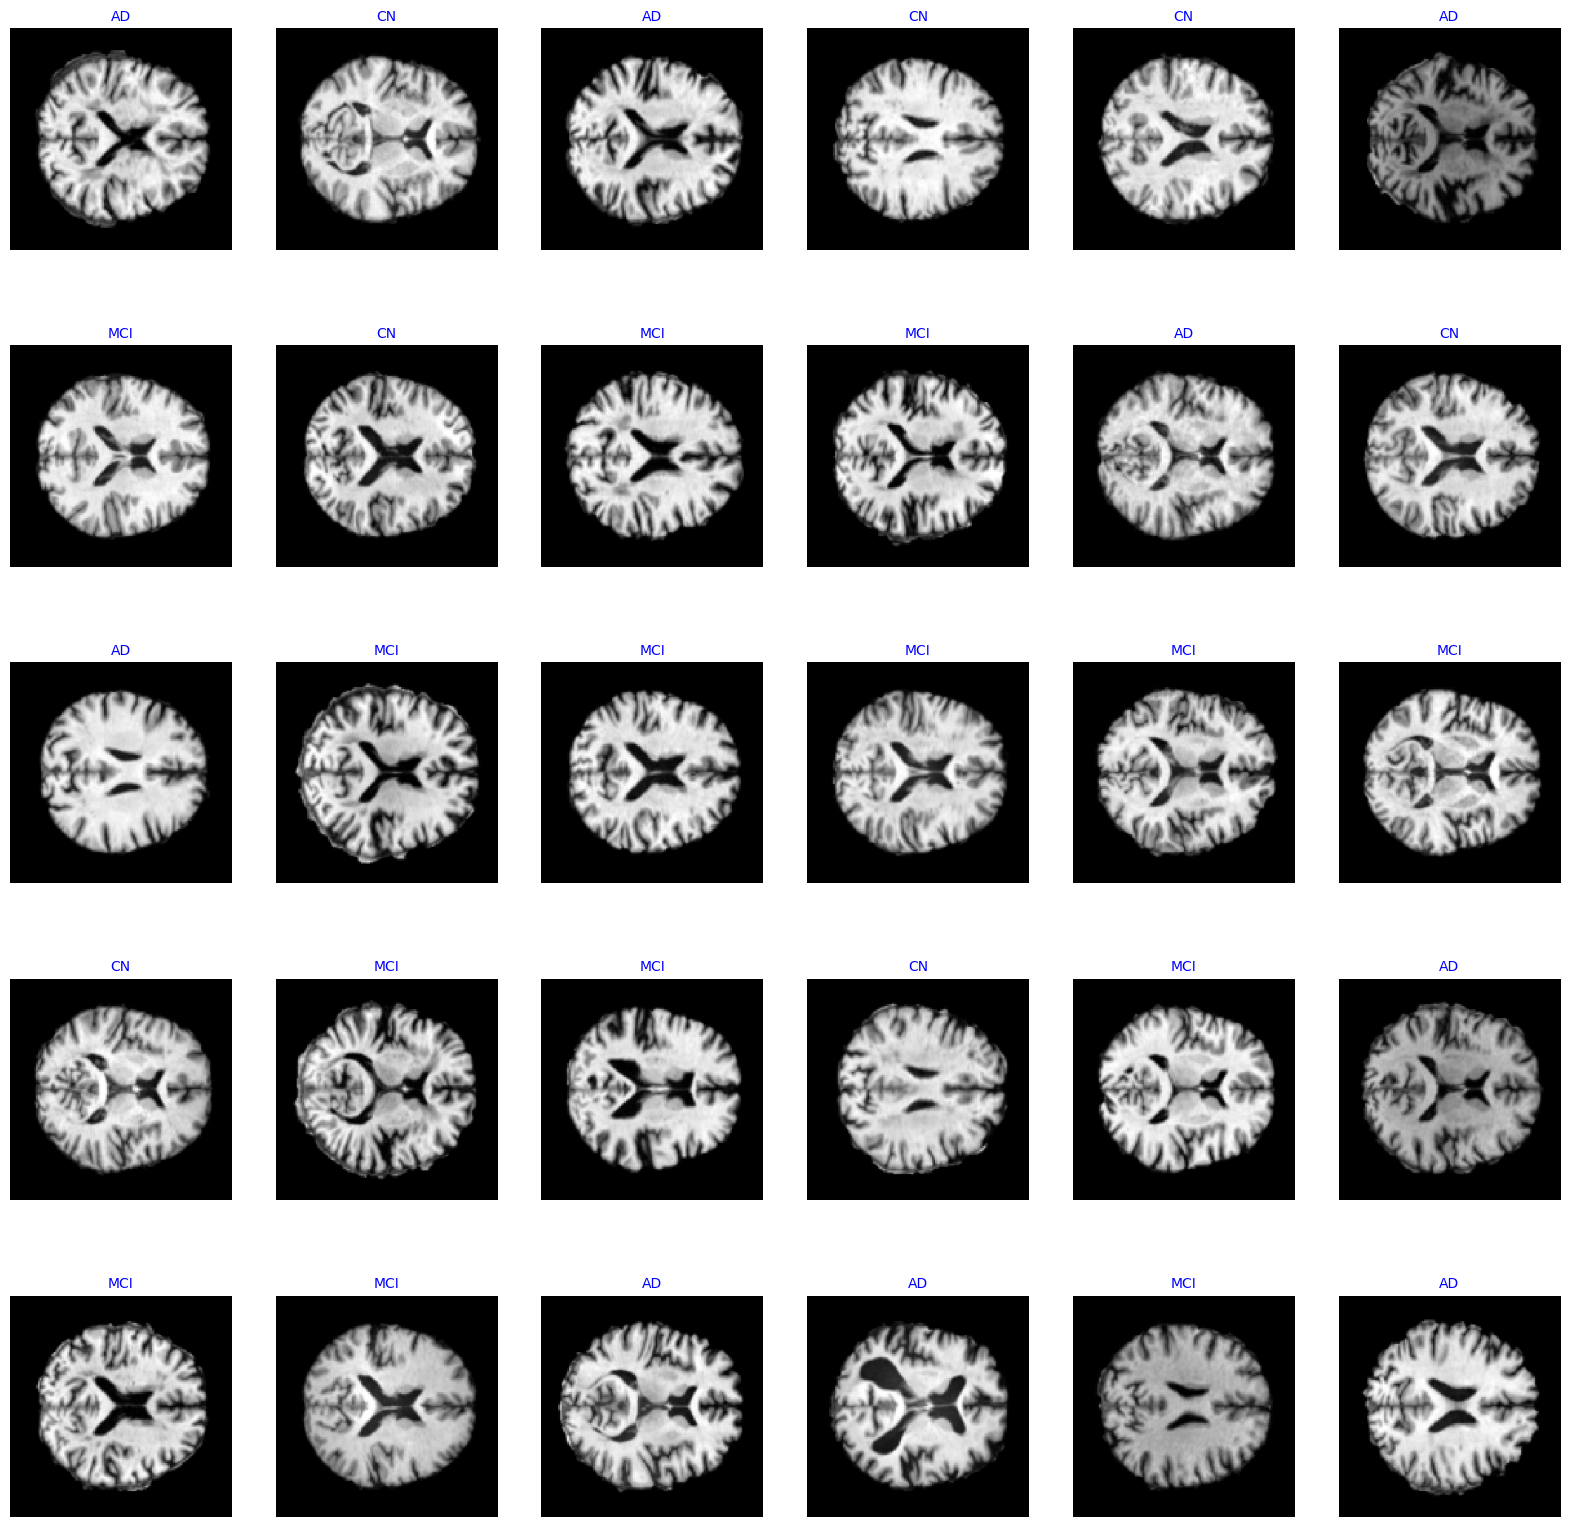

In [36]:
g_dict = train_data.class_indices      # defines dictionary {'class': index}
classes = list(g_dict.keys())       # defines list of dictionary's kays (classes), classes names : string
images, labels = next(train_data)      # get a batch size samples from the generator

plt.figure(figsize= (20, 24))

for i in range(30):
    plt.subplot(6, 6, i + 1)
    image = images[i]/255.0
    plt.imshow(image)
    index = np.argmax(labels[i])  # get image index
    class_name = classes[index]   # get class of image
    plt.title(class_name, color= 'blue', fontsize= 10)
    plt.axis('off')

In [37]:
#computing class weights
class_labels = list(train_data.classes)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes = np.unique(class_labels),
    y = class_labels
)

dict_weights = {i: weight for i, weight in enumerate(class_weights)}
dict_weights

{0: np.float64(1.7028688524590163),
 1: np.float64(0.7773620205799813),
 2: np.float64(0.8878205128205128)}

In [11]:
base_model = tf.keras.applications.EfficientNetV2B2(
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

len(base_model.layers)

I0000 00:00:1775150848.846775      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775150848.852805      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


35839040/35839040 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


349

In [12]:
len(train_data.class_indices)

3

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(300,300,3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(256,activation="relu",kernel_regularizer = tf.keras.regularizers.l2(0.005)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(len(train_data.class_indices),activation="softmax")
])

model.compile(optimizer=tf.keras.optimizers.Adamax(learning_rate=0.0010), loss="categorical_crossentropy",metrics=["accuracy"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b2 (Functional)  │ (None, 10, 10, 1408)   │     8,769,374 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       360,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,130,849 (34.83 MB)

 Trainable params: 361,475 (1.38 MB)

 Non-trainable params: 8,769,374 (33.45 MB)

In [14]:
artifacts_folder_path = os.path.join(os.getcwd(),"artifacts")
os.makedirs(artifacts_folder_path,exist_ok=True)

In [15]:
#creaing callbacks and fitting model
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(artifacts_folder_path,'EfficientNet_Alzheimer-s_model.keras'),
        monitor='val_loss',
        save_best_only=True
    )
]

history1 = model.fit(
    train_data,
    validation_data = (test_data),
    steps_per_epoch=len(train_data),
    validation_steps=len(test_data),
    epochs=5,
    callbacks=callbacks,
    class_weight=dict_weights
)

Epoch 1/5


I0000 00:00:1775150878.878589     155 service.cc:152] XLA service 0x7c969421b970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775150878.878630     155 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775150878.878634     155 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775150881.867662     155 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-02 17:28:10.247337: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 17:28:10.395590: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 17:28:11.268702: E external/local_xl

 531/1559 ━━━━━━━━━━━━━━━━━━━━ 3:03 178ms/step - accuracy: 0.3830 - loss: 2.5466

2026-04-02 17:30:07.795378: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 17:30:07.929688: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 17:30:08.719055: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 17:30:08.854582: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 17:30:10.236781: E external/local_xla/xla/stream_

1559/1559 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.4005 - loss: 2.0472

2026-04-02 17:35:48.975111: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 17:35:49.112259: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 17:35:49.892697: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 17:35:50.031691: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 17:35:51.366808: E external/local_xla/xla/stream_

1559/1559 ━━━━━━━━━━━━━━━━━━━━ 493s 290ms/step - accuracy: 0.4005 - loss: 2.0469 - val_accuracy: 0.5004 - val_loss: 1.1371 - learning_rate: 0.0010
Epoch 2/5
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 278s 178ms/step - accuracy: 0.4371 - loss: 1.1452 - val_accuracy: 0.3019 - val_loss: 1.1548 - learning_rate: 0.0010
Epoch 3/5
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 298s 191ms/step - accuracy: 0.4267 - loss: 1.1034 - val_accuracy: 0.3032 - val_loss: 1.1493 - learning_rate: 0.0010
Epoch 4/5
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 275s 176ms/step - accuracy: 0.4305 - loss: 1.0892 - val_accuracy: 0.5152 - val_loss: 1.0449 - learning_rate: 0.0010
Epoch 5/5
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 254s 163ms/step - accuracy: 0.4441 - loss: 1.0817 - val_accuracy: 0.4641 - val_loss: 1.0769 - learning_rate: 0.0010


In [25]:
for layer in base_model.layers[-200:]:
  layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adamax(learning_rate=0.0001), loss="categorical_crossentropy",metrics=["accuracy"])


history2 = model.fit(
    train_data,
    validation_data = (test_data),
    steps_per_epoch=len(train_data),
    validation_steps=len(test_data),
    epochs=8,
    callbacks=callbacks,
    class_weight=dict_weights
)

Epoch 1/8
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 459s 253ms/step - accuracy: 0.5853 - loss: 0.8808 - val_accuracy: 0.5091 - val_loss: 1.0776 - learning_rate: 1.0000e-04
Epoch 2/8
1559/1559 ━━━━━━━━━━━━━━━━━━━━ 348s 223ms/step - accuracy: 0.6593 - loss: 0.7527 - val_accuracy: 0.5050 - val_loss: 1.1803 - learning_rate: 1.0000e-04
Epoch 3/8
  71/1559 ━━━━━━━━━━━━━━━━━━━━ 4:42 190ms/step - accuracy: 0.7130 - loss: 0.6722

KeyboardInterrupt: 

In [17]:
#converting history into a dataframe for easier plotting
history1 = pd.DataFrame(history1.history)
history1["epochs"] = history1.index + 1
history1

,accuracy,loss,val_accuracy,val_loss,learning_rate,epochs
0,0.415283,1.583906,0.500377,1.137130,0.001,1
1,0.433032,1.129081,0.301885,1.154792,0.001,2
2,0.434637,1.096422,0.303243,1.149332,0.001,3
3,0.436041,1.087329,0.515234,1.044894,0.001,4
4,0.441075,1.082892,0.464103,1.076938,0.001,5


In [18]:
history2 = pd.DataFrame(history2.history)
history2["epochs"] = history2.index + history1["epochs"].max()+1
history2

,accuracy,loss,val_accuracy,val_loss,learning_rate,epochs
0,0.506819,1.001263,0.495324,1.023151,0.0001,6
1,0.596430,0.859639,0.514555,1.060008,0.0001,7
2,0.674087,0.727289,0.518326,1.164639,0.0001,8
3,0.733233,0.612702,0.517421,1.325665,0.0001,9


In [19]:
history = pd.concat([history1,history2])
history

,accuracy,loss,val_accuracy,val_loss,learning_rate,epochs
0,0.415283,1.583906,0.500377,1.137130,0.0010,1
1,0.433032,1.129081,0.301885,1.154792,0.0010,2
2,0.434637,1.096422,0.303243,1.149332,0.0010,3
3,0.436041,1.087329,0.515234,1.044894,0.0010,4
4,0.441075,1.082892,0.464103,1.076938,0.0010,5
0,0.506819,1.001263,0.495324,1.023151,0.0001,6
1,0.596430,0.859639,0.514555,1.060008,0.0001,7
2,0.674087,0.727289,0.518326,1.164639,0.0001,8
3,0.733233,0.612702,0.517421,1.325665,0.0001,9


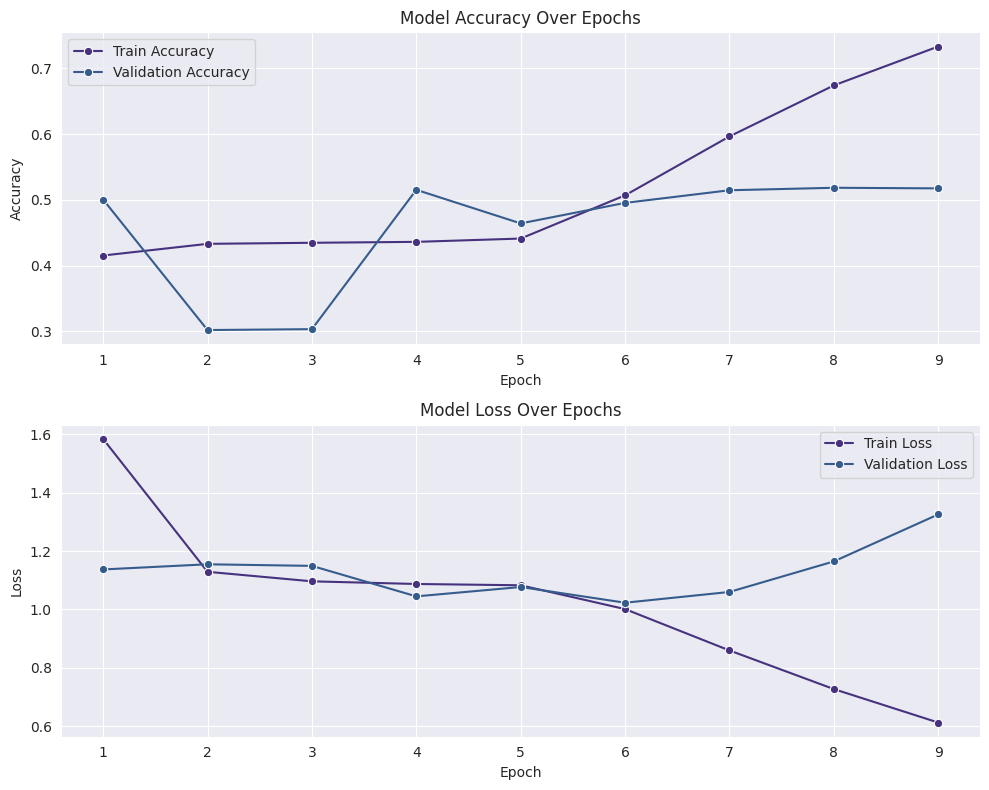

In [20]:
fig,axes = plt.subplots(2,1, figsize=(10,8))

# Accuracy plot
sns.lineplot(data=history, x="epochs", y="accuracy", label="Train Accuracy", marker="o", ax=axes[0])
sns.lineplot(data=history, x="epochs", y="val_accuracy", label="Validation Accuracy", marker="o", ax=axes[0])
axes[0].set_title("Model Accuracy Over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].set_xticks(history['epochs'])

# Loss plot
sns.lineplot(data=history, x="epochs", y="loss", label="Train Loss", marker="o", ax=axes[1])
sns.lineplot(data=history, x="epochs", y="val_loss", label="Validation Loss", marker="o", ax=axes[1])
axes[1].set_title("Model Loss Over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].set_xticks(history['epochs'])


plt.tight_layout()
plt.show()

In [21]:
# Evaluate on test_set
loss_test, acc_test = model.evaluate(test_data, verbose=0)
print('loss_test =>', loss_test)
print('acc_test =>', acc_test)

loss_test => 1.0231505632400513
acc_test => 0.4953242838382721


In [22]:
#getting predictions
predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis = 1)
y_true = test_data.classes

415/415 ━━━━━━━━━━━━━━━━━━━━ 63s 129ms/step


In [23]:
#printing classification report and f1score
report = classification_report(y_true, y_pred, target_names=list(test_data.class_indices.keys()), output_dict=True)
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=list(test_data.class_indices.keys())))
weighted_f1_score = report['weighted avg']['f1-score']
print(f"Weighted Average F1-score: {weighted_f1_score:.4f}")

Classification Report:
              precision    recall  f1-score   support

          AD       0.27      0.44      0.33      2460
          CN       0.65      0.62      0.64      5880
         MCI       0.51      0.38      0.43      4920

    accuracy                           0.50     13260
   macro avg       0.48      0.48      0.47     13260
weighted avg       0.53      0.50      0.50     13260

Weighted Average F1-score: 0.5036


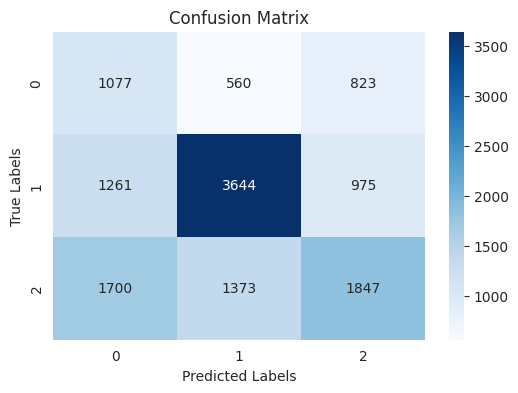

In [24]:
# Plotting Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()